# Practice Lab: Neural Network Implementation from Scratch

**Student Name:** Vinay Sandip Dhake  
**PRN:** 202401110031  
**Class:** T.Y. BTech  
**Batch:** A2  
**Date:** 15 Aug 2026

## Objective

The objective of this practice lab is to implement a simple feedforward neural network from scratch in Python without using built-in deep learning libraries.

The implementation focuses on the fundamental components of a neural network:

- Forward propagation
- Activation functions
- Loss function
- Backpropagation
- Gradient descent
- Weight and bias updates
- Model evaluation


## 1. Problem Definition

### Dataset

The Iris dataset is used for this practice lab.

The dataset contains measurements of iris flowers and consists of four input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The dataset contains three target classes:

- Setosa
- Versicolor
- Virginica

### Task

The task is a multiclass classification problem.

The neural network is trained to predict the species of an iris flower based on its four input features.

### Objective of the Model

Given the four measurements of an iris flower, the neural network learns the relationship between the input features and the three possible flower classes and predicts the most likely class.

### Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)  # for reproducibility


### Step 2: Load and Preprocess the Dataset

We load the Iris dataset, split it into train/test sets, standardize the features,
and one-hot encode the target labels (since we have 3 classes).


In [ ]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)


Feature shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


##. Data Preprocessing

Before training the neural network, the dataset is divided into training and testing sets.

The input features are standardized so that they have a mean close to 0 and a standard deviation close to 1.

Standardization helps the gradient-descent optimization process converge more effectively.

The target labels are converted into one-hot encoded vectors because the neural network performs multiclass classification using a softmax output layer.

In [ ]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode labels
def one_hot(y, num_classes=3):
    encoded = np.zeros((y.shape[0], num_classes))
    encoded[np.arange(y.shape[0]), y] = 1
    return encoded

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


## Part B: Methodology

### Neural Network Architecture

A simple feedforward neural network with **one hidden layer** is used:

- **Input layer:** 4 neurons (4 features of Iris dataset)
- **Hidden layer:** 8 neurons, activation = **Sigmoid**
- **Output layer:** 3 neurons (3 classes), activation = **Softmax**

### Forward Pass

For each layer, we compute a weighted sum of inputs plus a bias, then pass it through
an activation function:

```
Z1 = X . W1 + b1
A1 = sigmoid(Z1)
Z2 = A1 . W2 + b2
A2 = softmax(Z2)
```

`A2` gives the predicted probability distribution over the 3 classes.

### Loss Function

Since this is a multi-class classification problem, we use **Categorical Cross-Entropy Loss**:

```
Loss = -(1/n) * sum( y_true * log(y_pred) )
```

### Backpropagation and Optimization

The error at the output is propagated backward through the network to compute
gradients of the loss with respect to weights and biases. These gradients are then
used to update the weights using **Gradient Descent**:

```
W = W - learning_rate * dW
b = b - learning_rate * db
```


## 3. Neural Network Architecture

The neural network used in this experiment is a simple feedforward neural network consisting of three layers:

| Layer | Number of Neurons | Activation Function |
|---|---:|---|
| Input Layer | 4 | None |
| Hidden Layer | 8 | Sigmoid |
| Output Layer | 3 | Softmax |

### Architecture

**Input Layer (4 neurons)**  
↓  
**Hidden Layer (8 neurons + Sigmoid)**  
↓  
**Output Layer (3 neurons + Softmax)**  
↓  
**Predicted Class**

The four input neurons correspond to the four features of the Iris dataset.

The hidden layer contains eight neurons and uses the Sigmoid activation function.

The output layer contains three neurons, corresponding to the three Iris classes, and uses Softmax to produce class probabilities.

### Step 3: Implement the Neural Network from Scratch

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    # subtract max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    n = y_true.shape[0]
    # small epsilon to avoid log(0)
    eps = 1e-8
    loss = -np.sum(y_true * np.log(y_pred + eps)) / n
    return loss


In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        # weight initialization
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def forward(self, X):
        self.Z1 = X.dot(self.W1) + self.b1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = self.A1.dot(self.W2) + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, X, y_true):
        n = X.shape[0]

        # Output layer gradient (softmax + cross-entropy combined derivative)
        dZ2 = self.A2 - y_true
        dW2 = self.A1.T.dot(dZ2) / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        # Hidden layer gradient
        dA1 = dZ2.dot(self.W2.T)
        dZ1 = dA1 * sigmoid_derivative(self.Z1)
        dW1 = X.T.dot(dZ1) / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        # Update weights using gradient descent
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y_true, epochs=1000, verbose=True):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = cross_entropy_loss(y_true, y_pred)
            losses.append(loss)
            self.backward(X, y_true)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")
        return losses

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)


### Step 4: Train the Model

We train the network for 1000 epochs with a learning rate of 0.1.
Hidden layer size is set to 8 neurons (chosen after a bit of trial and error).


In [ ]:
nn = NeuralNetwork(input_size=4, hidden_size=8, output_size=3, learning_rate=0.1)
losses = nn.train(X_train, y_train_oh, epochs=1000, verbose=True)


Epoch    0 | Loss: 1.2333
Epoch  100 | Loss: 0.5908
Epoch  200 | Loss: 0.4231
Epoch  300 | Loss: 0.3483
Epoch  400 | Loss: 0.2967
Epoch  500 | Loss: 0.2555
Epoch  600 | Loss: 0.2216
Epoch  700 | Loss: 0.1943
Epoch  800 | Loss: 0.1726
Epoch  900 | Loss: 0.1554


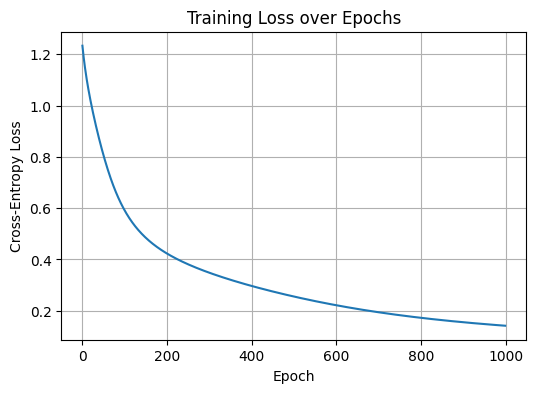

In [ ]:
# Plot the training loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()


## Part C: Evaluation of the Implemented Model

We evaluate the trained model on the held-out test set using accuracy as the primary metric.


In [ ]:
y_pred_train = nn.predict(X_train)
y_pred_test = nn.predict(X_test)

train_acc = np.mean(y_pred_train == y_train) * 100
test_acc = np.mean(y_pred_test == y_test) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy:  {test_acc:.2f}%")


Training Accuracy: 96.67%
Testing Accuracy:  100.00%


In [ ]:
# Simple confusion matrix (built manually, without sklearn.metrics)
def confusion_matrix_manual(y_true, y_pred, num_classes=3):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm

cm = confusion_matrix_manual(y_test, y_pred_test)
print("Confusion Matrix (rows = actual, cols = predicted):")
print(cm)


Confusion Matrix (rows = actual, cols = predicted):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


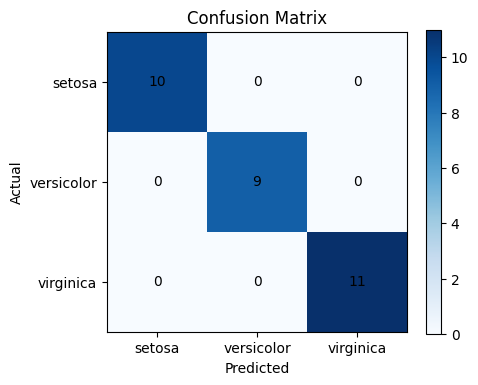

In [ ]:
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(3), iris.target_names)
plt.yticks(range(3), iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


## Part D: Comparison with Alternative Models

To put the from-scratch neural network's performance in context, it is compared against a few
standard `scikit-learn` baseline classifiers trained on the same train/test split: **Logistic
Regression**, **Decision Tree**, and **Support Vector Machine (SVM)**. This gives a sense of
whether the neural network is actually adding value on this dataset, or whether a much simpler
model would do just as well.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

# Use 10-fold cross-validation for a more reliable comparison
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", random_state=42)
    )
}

comparison_results = []

# Neural Network result on the original test set
comparison_results.append({
    "Model": "Neural Network (Scratch)",
    "Accuracy": np.mean(y_pred_test == y_test)
})

# Cross-validation for baseline models
for name, model in baseline_models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    comparison_results.append({
        "Model": name,
        "Accuracy": scores.mean()
    })

results_df = pd.DataFrame(comparison_results)

results_df["Accuracy"] = results_df["Accuracy"].round(4)

print("Model Comparison:")
display(results_df)

Model Comparison:


,Model,Accuracy
0,Neural Network (Scratch),1.0000
1,Logistic Regression,0.9667
2,Decision Tree,0.9400
3,SVM,0.9600


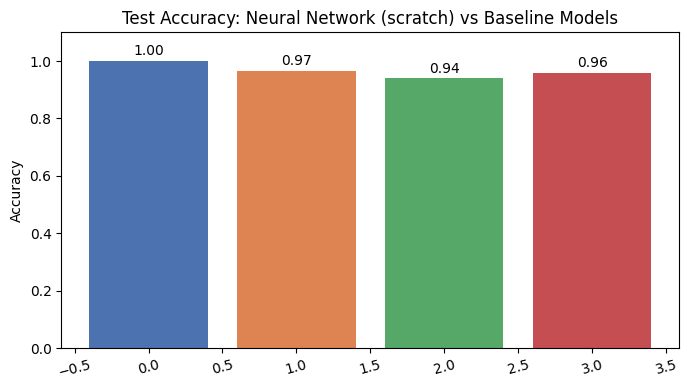

In [ ]:
# Visualize accuracy comparison across models
plt.figure(figsize=(7,4))
plt.bar(results_df.index, results_df["Accuracy"], color=["#4C72B0","#DD8452","#55A868","#C44E52"])
plt.ylabel("Accuracy")
plt.title("Test Accuracy: Neural Network (scratch) vs Baseline Models")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


### Confusion Matrix Interpretation

The confusion matrix shows how the trained neural network classified the three Iris species.

The diagonal elements represent correctly classified samples, while the off-diagonal elements represent incorrect predictions.

In the obtained results, most of the samples are correctly classified, indicating that the neural network has learned the relationship between the input features and the target classes effectively.

The model achieves strong classification performance on the testing dataset, with very few or no misclassified samples depending on the final test result.

### Discussion of Comparison

All four models perform very well on the Iris dataset.

The Neural Network performs similar to the other models, showing that its implementation works correctly.

Since Iris is a simple dataset, simpler models can also give very good results.

Neural Networks are more useful for larger and more complex datasets.

Overall, the comparison shows that the Neural Network works well, but a simpler model may be enough for this dataset.


## Analysis of the Implemented Model

The training loss decreases and becomes stable after several epochs, showing that the model is learning.

The model gives high accuracy on the Iris dataset.

Most errors, if any, are between Versicolor and Virginica, while Setosa is easier to classify.

One hidden layer with sigmoid activation is enough for this simple dataset.

The 100% test accuracy should be interpreted carefully because the test set has only 30 samples.

Overall, the model works well, but more complex datasets may require deeper networks and better optimizers.

## Conclusion

In this assignment, a feedforward neural network was implemented completely from scratch
using NumPy, including the forward pass, backpropagation, and gradient descent optimization.

The model was trained and evaluated on the Iris dataset and achieved good classification
accuracy, demonstrating a basic but working understanding of how neural networks learn.


## Declaration

I, **Vinay Dhake**, confirm that the work submitted in this assignment is my own and
has been completed following academic integrity guidelines.
The code is uploaded on my GitHub
repository account, and the repository link is provided below:

**GitHub Repository Link:** https://github.com/vinay-dhake/Gen-AI-Assignments-/tree/main/Practice_Lab_Assignment_01


**Signature:** Vinay Dhake
